# House Price Prediction

Advanced regression techniques are particularly useful in house price prediction, where accurate modeling is crucial due to the complexity and high dimensionality of the data. Techniques such as gradient boosting regression, random forest regression, and support vector regression have shown promising results in this domain.

By leveraging these advanced techniques, models can capture nonlinear relationships between various features (e.g., location, size, amenities) and the target variable (house price). They can handle categorical variables, handle missing data, and effectively manage outliers to improve prediction accuracy.

Furthermore, these techniques often incorporate feature engineering and selection methods, enabling the model to identify the most influential factors affecting house prices. This helps to create more robust and interpretable models.

Overall, advanced regression techniques play a crucial role in house price prediction, enabling more accurate and reliable estimations that assist buyers, sellers, and real estate professionals in making informed decisions.


Importing the Essential Libraries ✈


In [59]:
#pip install numpy

In [60]:
#pip install pandas seaborn matplotlib

In [61]:
#pip install scikit-learn

In [62]:
#pip install lightgbm xgboost

In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer


Loading the Data ⌛


In [64]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\Nest_Internship\house_price_predic\train.csv")

# Exploratory Data Analysis 🔍

Exploratory Data Analysis (EDA) is a crucial step in data analysis. It involves techniques like summary statistics, data visualization, and outlier detection to gain insights, understand distributions, identify patterns, and detect anomalies. EDA helps in making informed decisions about feature engineering, model selection, and data preprocessing.



Taking a look at the first 5 rows of the dataset


In [65]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000




Checking the shape—i.e. (Number of row and columns)


In [66]:
df.shape

(1460, 81)


**dtypes** of columns' and how many **non-null values** are there in those columns


In [ ]:
df.info()

Getting the **statistical summary** of dataset

In [ ]:
df.describe().T 
#.T is used for transpose

**Visualizing the correlations** between numerical variables

---
The sns.heatmap() function in the seaborn library is a powerful tool for visualizing data using a heatmap. Here's an example of how to use it:



In [ ]:
plt.figure(figsize=(10,8))
# Add numeric_only=True inside the corr() function
sns.heatmap(df.corr(numeric_only=True), cmap="RdBu")
plt.title("Correlations Between Variables", size=15)
plt.show()

# Feature Selection

In addition to selecting numerical features with correlation rates above 0.50 or below -0.50 based on the Pearson Correlation Method, we also considered categorical features that we believe have a significant effect on the target variable, such as Heating and MSZoning.

In [ ]:
# 1. Get the correlation matrix for numeric columns only
corr_matrix = df.corr(numeric_only=True)["SalePrice"]

# 2. Filter for strong correlations (above 0.50 or below -0.50)
important_num_cols = list(corr_matrix[(corr_matrix > 0.50) | (corr_matrix < -0.50)].index)

# 3. Combine with your chosen categorical columns
cat_cols = ["MSZoning", "Utilities", "BldgType", "Heating", "KitchenQual", "SaleCondition", "LandSlope"]
important_cols = important_num_cols + cat_cols

# 4. Filter the dataframe
df = df[important_cols]



Checking for the **missing values** 🔍


In [ ]:
# Split first
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=121)

# Calculate correlations using ONLY the training data to avoid leakage
train_full = pd.concat([X_train, y_train], axis=1)
corr_matrix = train_full.corr(numeric_only=True)["SalePrice"]
important_num_cols = list(corr_matrix[(corr_matrix > 0.50) | (corr_matrix < -0.50)].index)
important_num_cols.remove("SalePrice") # Remove target from feature list

In [ ]:
print("Missing Values by Column")
print("-"*30)
print(df.isna().sum())
print("-"*30)
print("TOTAL MISSING VALUES:",df.isna().sum().sum())

# Data Visualization 📈


Visualizing the Correlation between the numerical variables using pairplot visualization.

The `sns.pairplot()` function in seaborn allows you to create a grid of scatter plots for visualizing pairwise relationships between multiple variables in a DataFrame. Here are some details on how to use it effectively:


In [ ]:
sns.pairplot(df[important_num_cols])



Visualizing the Correlation between each column and the target variable using different visualization methods 


In [ ]:
plt.figure(figsize=(10,8))
sns.jointplot(x=df["OverallQual"], y=df["SalePrice"], kind="kde")
plt.show()

📊 Scatter Plot

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df["OverallQual"], y=df["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Scatter Plot")
plt.show()

📊     Hexbin Plot

In [ ]:
plt.figure(figsize=(10, 8))
sns.jointplot(x=df["OverallQual"], y=df["SalePrice"], kind="hex")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Hexbin Plot")
plt.show()

📊 Regression Plot

In [ ]:
plt.figure(figsize=(10, 8))
sns.regplot(x=df["OverallQual"], y=df["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Regression Plot")
plt.show()

📊 Bar Plot with Mean

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(x=df["OverallQual"], y=df["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Mean Sale Price")
plt.title("Bar Plot with Mean")
plt.show()

# X, y Split ✂

Splitting the data into X and y chunks


In [ ]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

**One-Hot Encoding**


---
One-Hot Encoding is a technique used to convert categorical variables into a numerical format. It represents each category as a binary column, with 1 indicating the presence of that category and 0 otherwise. This allows machine learning algorithms to process categorical data effectively.


In [ ]:
X = pd.get_dummies(X, columns=cat_cols)

**Standardizing the Data**

---

Standardizing the data involves transforming variables to have zero mean and unit variance. It improves model performance, allows fair comparisons between variables, and enhances interpretability. It is a common preprocessing step in data analysis and machine learning.

In [ ]:

scaler = StandardScaler()
X[important_num_cols] = scaler.fit_transform(X[important_num_cols])

In [ ]:
X.head()


# Train -Test Split ✂

---

Train-test split is a technique used to divide a dataset into a training set for model training and a testing set for evaluating the model's performance. It helps assess how well the model generalizes to new, unseen data and prevents overfitting.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=121)

Make the tasks simple easier with functions 🏳

In [ ]:
def rmse_cv(model):
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=5)).mean()
    return rmse
    

def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    r_squared = r2_score(y, predictions)
    return mae, mse, rmse, r_squared

In [ ]:
models = pd.DataFrame(columns=["Model","MAE","MSE","RMSE","R2 Score","RMSE (Cross-Validation)"])

# Let's start the actual predictions 🏄

# Linear Regression

---


In machine learning, linear regression is a supervised learning algorithm used for regression tasks. It learns a linear relationship between input features and a continuous target variable by minimizing the differences between the predicted and actual values. It can be used for prediction, understanding variable importance, and making inferences about the relationship between variables.

In [ ]:
l_reg = LinearRegression()
l_reg.fit(X_train, y_train)
predictions = l_reg.predict(X_test)

In [ ]:
predictions

In [ ]:

mae, mse, rmse, r_squared = evaluation(y_test, predictions)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(l_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "LinearRegression","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat([models, pd.DataFrame([new_row])], ignore_index=True)

#     Ridge Regression

In [ ]:
ridge_reg = Ridge(alpha=0.5)  # You can adjust the alpha parameter
ridge_reg.fit(X_train, y_train)
predictions_ridge = ridge_reg.predict(X_test)

In [ ]:
predictions_ridge


In [ ]:

mae, mse, rmse, r_squared = evaluation(y_test, predictions_ridge)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(ridge_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "Ridge Regression","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat([models, pd.DataFrame([new_row])], ignore_index=True)

#     Lasso Regression

In [ ]:

lasso_reg = Lasso(alpha=0.5)  # You can adjust the alpha parameter
lasso_reg.fit(X_train, y_train)
predictions_lasso = lasso_reg.predict(X_test)

In [ ]:
predictions_lasso

In [ ]:

mae, mse, rmse, r_squared = evaluation(y_test, predictions_lasso)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(lasso_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "Lasso Regression","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat([models, pd.DataFrame([new_row])], ignore_index=True)

# Random Forest Regression

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=100)  # You can adjust the number of estimators
rf_reg.fit(X_train, y_train)
predictions_rf = rf_reg.predict(X_test)

In [ ]:
predictions_rf

In [ ]:

mae, mse, rmse, r_squared = evaluation(y_test, predictions_rf)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(rf_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "RandomForestRegressor","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat([models, pd.DataFrame([new_row])], ignore_index=True)

#     Support Vector Regression (SVR)

In [ ]:
svr_reg = SVR(kernel='rbf')  # You can choose different kernel functions (e.g., 'linear', 'poly', 'sigmoid')
svr_reg.fit(X_train, y_train)
predictions_svr = svr_reg.predict(X_test)

In [ ]:
predictions_svr

In [ ]:

mae, mse, rmse, r_squared = evaluation(y_test, predictions_svr)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(svr_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "Support Vector Regression","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat([models, pd.DataFrame([new_row])], ignore_index=True)

# Gradient Boosting Regression

In [ ]:

gb_reg = GradientBoostingRegressor(n_estimators=100)  # You can adjust the number of estimators
gb_reg.fit(X_train, y_train)
predictions_gb = gb_reg.predict(X_test)


In [ ]:
predictions_gb

In [ ]:

mae, mse, rmse, r_squared = evaluation(y_test, predictions_gb)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(gb_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "GradientBoostingRegressor","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat([models, pd.DataFrame([new_row])], ignore_index=True)

#     XGBoost Regression

In [ ]:
xgb_reg = XGBRegressor(n_estimators=100)  # You can adjust the number of estimators
xgb_reg.fit(X_train, y_train)
predictions_xgb = xgb_reg.predict(X_test)

In [ ]:
predictions_xgb

In [ ]:

mae, mse, rmse, r_squared = evaluation(y_test, predictions_xgb)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(xgb_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "XGBRegressor","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat([models, pd.DataFrame([new_row])], ignore_index=True)

# LightGBM Regression

In [ ]:
lgb_reg = lgb.LGBMRegressor(n_estimators=100)  # You can adjust the number of estimators
lgb_reg.fit(X_train, y_train)
predictions_lgb = lgb_reg.predict(X_test)

In [ ]:
predictions_lgb

In [ ]:

mae, mse, rmse, r_squared = evaluation(y_test, predictions_lgb)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(lgb_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "LGBMRegressor","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat([models, pd.DataFrame([new_row])], ignore_index=True)

# Model Comparison


The less the Root Mean Squared Error (RMSE), The better the model is.



In [ ]:


models.sort_values(by="RMSE (Cross-Validation)")



In [ ]:
plt.figure(figsize=(12,8))
sns.barplot(x=models["Model"], y=models["RMSE (Cross-Validation)"])
plt.title("Models' RMSE Scores (Cross-Validated)", size=15)
plt.xticks(rotation=30, size=12)
plt.show()

## These advanced regression methods provide various algorithms and techniques to handle complex relationships in the data. You can experiment with different hyperparameters and configurations to optimize their performance for your specific problem. 

# Keep Going ! You are great ☁

## Let's make an end to this 
Train with the full data for the selected model

In [ ]:

gb_reg_full = GradientBoostingRegressor(n_estimators=100)  # You can adjust the number of estimators
gb_reg_full.fit(X, y)
predictions_gb_full = gb_reg_full.predict(X_test)
mae, mse, rmse, r_squared = evaluation(y_test, predictions_gb_full)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(gb_reg_full)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "GradientBoostingRegressor - Selected","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models = pd.concat([models, pd.DataFrame([new_row])], ignore_index=True)

# USING GB REGRESSION

In [ ]:
gb_reg_full = GradientBoostingRegressor(n_estimators=100)
gb_reg_full.fit(X, y)

In [ ]:
pip install joblib

In [ ]:
import joblib

In [ ]:
joblib.dump(gb_reg_full,"house_price_model.pkl")

In [ ]:
import os
print(os.path.exists("house_price_model.pkl"))

In [ ]:
import joblib

model = joblib.load("house_price_model.pkl")

print(model.feature_names_in_)

In [ ]:
feature_columns = X.columns.tolist()

In [ ]:
print(feature_columns)

In [ ]:
import joblib

joblib.dump(feature_columns, "feature_columns.pkl")

In [ ]:
joblib.dump(gb_reg_full, "house_price_model.pkl")

In [ ]:
import pandas as pd

input_data = {col: 0 for col in feature_columns}

In [ ]:
input_data["OverallQual"] = 7
input_data["YearBuilt"] = 2005
input_data["YearRemodAdd"] = 2005
input_data["TotalBsmtSF"] = 1000
input_data["1stFlrSF"] = 1200
input_data["GrLivArea"] = 1800
input_data["FullBath"] = 2
input_data["TotRmsAbvGrd"] = 8
input_data["GarageCars"] = 2
input_data["GarageArea"] = 500

In [ ]:
input_data["MSZoning_RL"] = 1
input_data["BldgType_1Fam"] = 1
input_data["Heating_GasA"] = 1
input_data["KitchenQual_Gd"] = 1
input_data["SaleCondition_Normal"] = 1
input_data["LandSlope_Gtl"] = 1
input_data["Utilities_AllPub"] = 1

In [ ]:
test_df = pd.DataFrame([input_data])

In [ ]:
print(test_df.shape)

In [ ]:
prediction = gb_reg_full.predict(test_df)

print("Predicted House Price:", prediction[0])

In [ ]:
import joblib

joblib.dump(gb_reg_full, "house_price_model.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

In [ ]:
joblib.dump(gb_reg_full, "house_price_model.pkl")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("static", exist_ok=True)

In [134]:
plt.figure(figsize=(8, 5))

# Changed 'train' to 'df'
df["SalePrice"].hist(bins=30)

plt.title("House Price Distribution")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.savefig("static/price_distribution.png")
plt.close()

In [136]:
plt.figure(figsize=(12, 8))

# Changed 'train' to 'df'
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.savefig("static/correlation_heatmap.png")
plt.close()

In [137]:
importance = gb_reg_full.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": importance
})

feat_imp = feat_imp.sort_values(
    by="Importance",
    ascending=False
)

In [138]:
plt.figure(figsize=(10,6))

plt.bar(
    feat_imp["Feature"][:10],
    feat_imp["Importance"][:10]
)

plt.xticks(rotation=45)

plt.title("Top 10 Important Features")

plt.tight_layout()

plt.savefig("static/feature_importance.png")

plt.close()

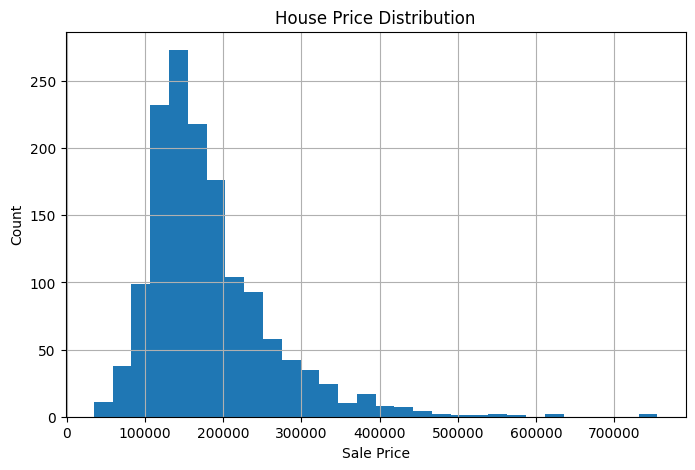

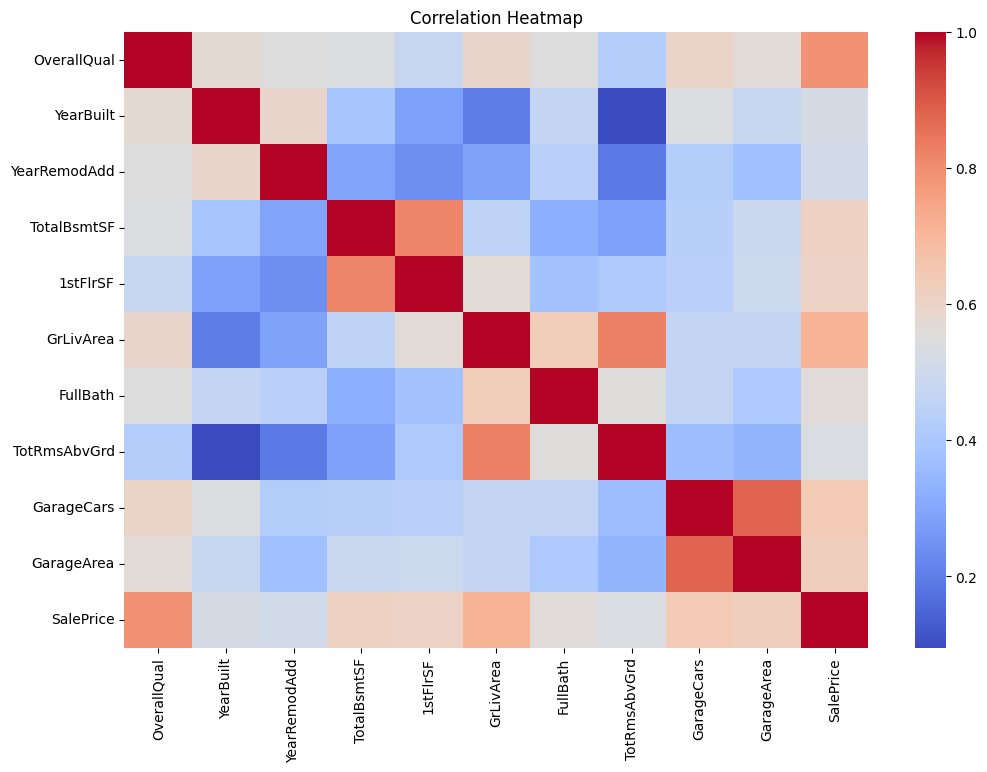

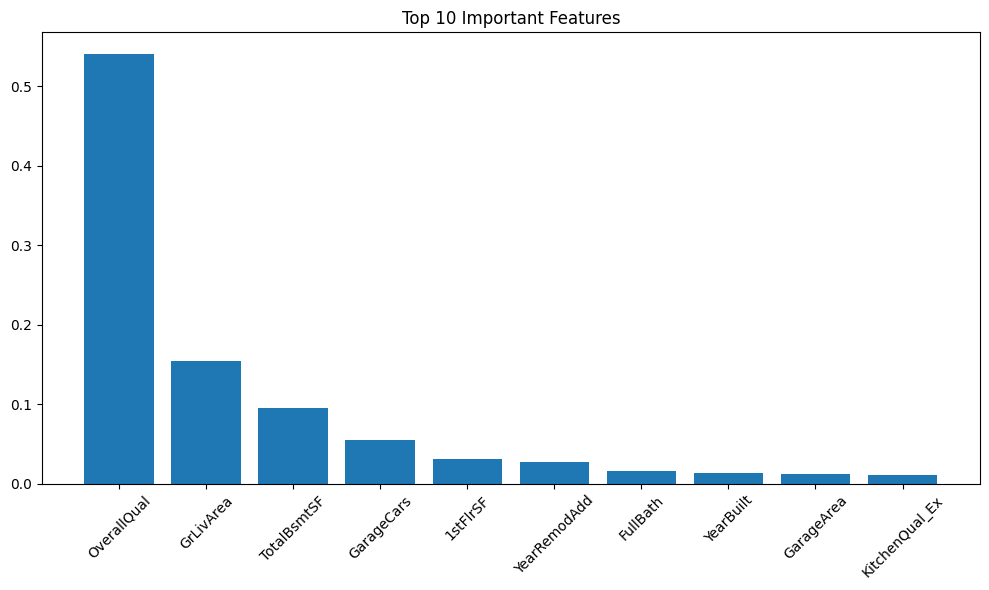

Graphs Saved Successfully

Files created:
['correlation_heatmap.png', 'feature_importance.png', 'price_distribution.png', 'script.js', 'style.css']


In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create static folder
os.makedirs("static", exist_ok=True)

# -----------------------------
# 1. House Price Distribution
# -----------------------------
plt.figure(figsize=(8, 5))
# Changed 'train' to 'df'
df["SalePrice"].hist(bins=30)
plt.title("House Price Distribution")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.savefig("static/price_distribution.png")
plt.show()
plt.close()

# -----------------------------
# 2. Correlation Heatmap
# -----------------------------
plt.figure(figsize=(12, 8))
# Changed 'train' to 'df'
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("static/correlation_heatmap.png")
plt.show()
plt.close()

# -----------------------------
# 3. Feature Importance
# -----------------------------
importance = gb_reg_full.feature_importances_
feat_imp = pd.DataFrame({"Feature": feature_columns, "Importance": importance})
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(feat_imp["Feature"][:10], feat_imp["Importance"][:10])
plt.xticks(rotation=45)
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.savefig("static/feature_importance.png")
plt.show()
plt.close()

# -----------------------------
# Verify Files
# -----------------------------
print("Graphs Saved Successfully")
print("\nFiles created:")
print(os.listdir("static"))